In [1]:
!pip install sqlalchemy pymysql openpyxl requests python-dotenv --quiet


In [20]:
import datetime
import requests
import json
import os

from dotenv import load_dotenv
import pandas as pd
import sqlalchemy as sa
from sqlalchemy import create_engine, text, MetaData, Table
from sqlalchemy.orm import sessionmaker

In [ ]:
Завдання 1: Простий запит (1 бал)
Ми працюємо з БД Classicmodels.

Виведіть інформацію про продукти на складі з наступними полями:

назва продукту (productName)
лінійка продукту (productLine)
кількість на складі (quantityInStock)
ціна закупки (buyPrice)
Зчитайте дані з БД з допомогою pd.read_sql() з SQLAlchemy engine, який ви створили на етапі підготовки.

Виведіть перші 10 продуктів, відсортованих за кількістю на складі (від більшої кількості до меншої).

In [18]:
from dotenv import load_dotenv
load_dotenv(override=True)

True

In [24]:
import pandas as pd
query = """
SELECT
    productName,
    productLine,
    quantityInStock,
    buyPrice
FROM products
ORDER BY quantityInStock DESC
LIMIT 10;
"""

df_products = pd.read_sql(query, engine)
df_products

,productName,productLine,quantityInStock,buyPrice
0,2002 Suzuki XREO,Motorcycles,9997,66.27
1,1995 Honda Civic,Classic Cars,9772,93.89
2,America West Airlines B757-200,Planes,9653,68.80
3,2002 Chevy Corvette,Classic Cars,9446,62.11
4,1932 Model A Ford J-Coupe,Vintage Cars,9354,58.48
5,1982 Ducati 996 R,Motorcycles,9241,24.14
6,1912 Ford Model T Delivery Wagon,Vintage Cars,9173,46.91
7,1976 Ford Gran Torino,Classic Cars,9127,73.49
8,1968 Dodge Charger,Classic Cars,9123,75.16
9,1965 Aston Martin DB5,Classic Cars,9042,65.96


In [ ]:
Завдання 2: Аналітика замовлень за 2004 рік (3 бали)
Виведіть детальну інформацію про замовлення за 2004 рік з наступними полями:

Номер замовлення (orderNumber)
Дата замовлення (orderDate)
Статус замовлення (status)
Ім'я клієнта (customerName)
Країна клієнта (country)
Загальна сума замовлення (сума всіх orderdetails.quantityOrdered * orderdetails.priceEach)
Використайте JOIN для об'єднання таблиць orders, customers, orderdetails. Додайте параметризацію за роком (тільки замовлення за 2004 рік).

Використайте text() та named parameters для формування запиту з SQLAlchemy.

Після отримання даних з БД проведіть обчислення з Python та напишіть висновки:

Побудуйте стовпчасту діаграму суми замовлень по країнам і напишіть, в якій країні найбільша сума замовлень за 2004 рік.
В країні з найбільшою кількістю замовлень знайдіть клієнта, який зробив замовлень на найбільшу суму і виведіть імʼя цього клієнта, 
на яку суму він зробив замовлень і який % від всіх замовлень в цій країні становить його сума замовлень за рік.

In [69]:
from sqlalchemy import text

query = text("""
SELECT
    o.orderNumber,
    o.orderDate,
    o.status,
    c.customerName,
    c.country,
    d.quantityOrdered * d.priceEach AS total_price
FROM classicmodels.orders o
JOIN classicmodels.customers c ON o.customerNumber = c.customerNumber
JOIN classicmodels.orderdetails d ON o.orderNumber = d.orderNumber
WHERE o.orderDate BETWEEN :start_date AND :end_date;
""")

start_date = '2004-01-01'
end_date = '2004-12-31'

df_analysis = pd.read_sql(
    query,
    engine,
    params={"start_date": start_date, "end_date": end_date}
)
df_analysis.head();

In [32]:
%pip install matplotlib

   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ------------------- -------------------- 4.5/9.3 MB 26.4 MB/s eta 0:00:01
   ---------------------------------------- 9.3/9.3 MB 25.8 MB/s  0:00:00
   ---------------------------------------- 0.0/2.5 MB ? eta -:--:--
   ---------------------------------------- 2.5/2.5 MB 29.8 MB/s  0:00:00
   ---------------------------------------- 0.0/7.2 MB ? eta -:--:--
   ---------------------------------------- 7.2/7.2 MB 33.1 MB/s  0:00:00

   ---------------------------------------- 0/7 [pyparsing]
   ---------------------------------------- 0/7 [pyparsing]
   ---------------------------------------- 0/7 [pyparsing]
   ---------------------------------------- 0/7 [pyparsing]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ----------------

In [34]:
grouped = df_analysis.groupby("country", as_index=False)["total_price"].sum()

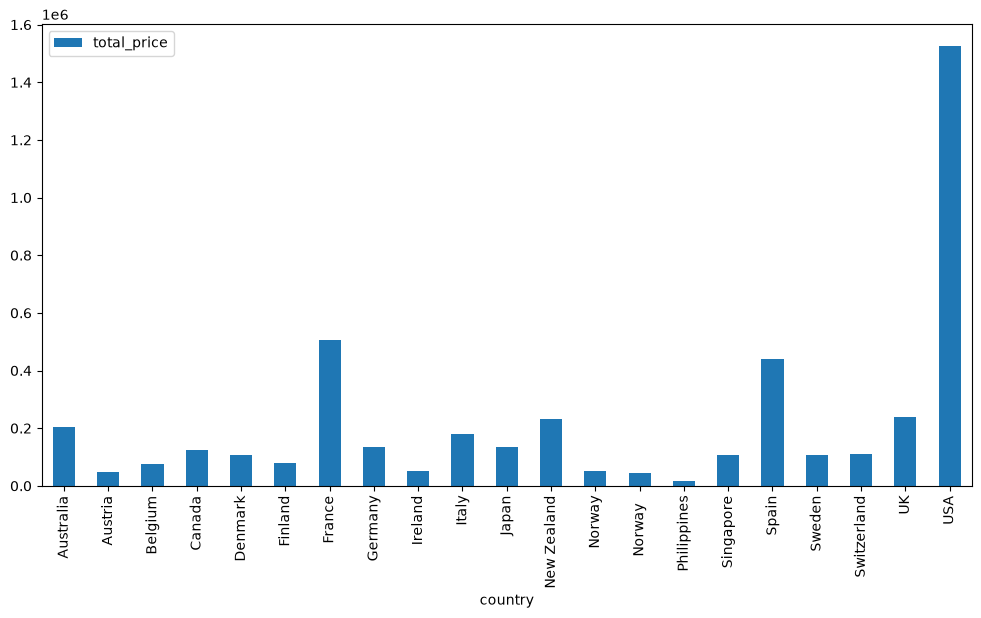

In [70]:
grouped.plot.bar(x="country", y="total_price", figsize=(12, 6));

In [ ]:
Найбільша сума замовлень за 2004 рік була в USA.

In [36]:
orders_by_country = df_analysis.groupby("country")["orderNumber"].nunique()
top_country = orders_by_country.idxmax()

In [37]:
top_country

'USA'

In [38]:
df_country = df_analysis[df_analysis["country"] == top_country]

In [39]:
df_country

,orderNumber,orderDate,status,customerName,country,total_price
3,10278,2004-08-06,Shipped,Signal Gift Stores,USA,3898.10
4,10278,2004-08-06,Shipped,Signal Gift Stores,USA,2461.46
5,10278,2004-08-06,Shipped,Signal Gift Stores,USA,2121.35
6,10278,2004-08-06,Shipped,Signal Gift Stores,USA,3424.03
7,10278,2004-08-06,Shipped,Signal Gift Stores,USA,4581.72
...,...,...,...,...,...,...
1395,10219,2004-02-10,Shipped,Signal Collectibles Ltd.,USA,5702.66
1396,10219,2004-02-10,Shipped,Signal Collectibles Ltd.,USA,653.52
1397,10219,2004-02-10,Shipped,Signal Collectibles Ltd.,USA,1666.70
1401,10243,2004-04-26,Shipped,Diecast Collectables,USA,5257.89


In [40]:
sales_by_customer = df_country.groupby("customerName")["total_price"].sum()
top_customer = sales_by_customer.idxmax()
top_sum = sales_by_customer.max()

In [41]:
top_customer 


'Mini Gifts Distributors Ltd.'

In [42]:
top_sum

np.float64(231562.53)

In [43]:
country_total = df_country["total_price"].sum()
percent = top_sum / country_total * 100


In [44]:
 percent

np.float64(15.16951084790619)

In [45]:
print(f"Країна з найбільшою кількістю замовлень: {top_country} ({orders_by_country.max()} замовлень)")
print(f"Клієнт: {top_customer}")
print(f"Сума замовлень: {top_sum:,.2f}")
print(f"Частка від усіх замовлень країни: {percent:.2f}%")

Країна з найбільшою кількістю замовлень: USA (53 замовлень)
Клієнт: Mini Gifts Distributors Ltd.
Сума замовлень: 231,562.53
Частка від усіх замовлень країни: 15.17%


In [ ]:
Завдання 3: Аналітичний запит - Топ продуктів по продажах (6 балів)
В цьому завданні ви отримуєте 1 бал за правильний SQL запит і по 1 балу за кожне завдання з Python.

Проведіть аналіз прибутковості продуктів та для цього дістаньте з БД інформацію з наступними полями:

Назва продукту
- Лінійка продукту (productLine)
- Загальний дохід з цього продукту (сума quantity * priceEach)
- Ранг продукту по доходу (тобто яке місце посідає цей продукт за доходом серед усіх продуктів в нашому магазині)
- Який відсоток від загального доходу компанії складає цей продукт
- Різниця з середнім доходом по лінійці продукту (в %)
Відсортуйте дані за спаданням значень колонки "Який відсоток від загального доходу компанії складає цей продукт".

При створенні SQL запиту вам можуть стати в нагоді:

CTE для розрахунку доходу по кожному продукту
Віконні функції для ранжування та порівняння з середнім
Після отримання даних з БД проведіть обчислення (де треба) з Python та напишіть висновки:

1.Який відсоток від загального доходу складає ТОП1 продукт і що це за продукт?
2.Створіть стовпчикову діаграму топ-10 продуктів по доходу. В скільки разів відрізняється
сумарний дохід за ТОП1 продуктом від 10го продукту за сумою доходу?
3.Створіть кругову діаграму розподілу доходу по лініях продуктів.
Який відсоток від всіх продажів становлять продажі за ТОП2 лініями сумарно?
4.Розрахуйте та виведіть за принципом Парето (80/20) - скільки продуктів дають 80% доходу. 
Тобто нам треба знайти кількість продуктів сумарне значення "відсотку від загального доходу компанії", 
яких складає 80 починаючи з продукту з найбільшим цим відсотком.
    
Зробіть ще будь-яке аналітичне дослідження, яке дасть нам більше розуміння наших даних, що ми дістали в БД в цьому завданні.
Сформоване питання до даних і обчислення має бути обовʼязково. Візуалізація - опціонально.
Візуалізацію можна створювати з будь-якою бібліотекою на ваш вибір.

In [47]:

data = text("""
WITH product_revenue AS (
    SELECT
        p.productCode,
        p.productName,
        p.productLine,
        SUM(od.quantityOrdered * od.priceEach) AS total_revenue
    FROM classicmodels.products p
    JOIN classicmodels.orderdetails od ON p.productCode = od.productCode
    GROUP BY p.productCode, p.productName, p.productLine
)
SELECT
    productName,
    productLine,
    total_revenue,
    RANK() OVER (ORDER BY total_revenue DESC) AS revenue_rank,
    ROUND(total_revenue * 100.0 / SUM(total_revenue) OVER (), 2) AS pct_of_total_revenue,
    ROUND(
        (total_revenue / AVG(total_revenue) OVER (PARTITION BY productLine) - 1) * 100, 2
    ) AS diff_from_line_avg_pct
FROM product_revenue
ORDER BY pct_of_total_revenue DESC;
""")

df_products_revenue = pd.read_sql(data, engine)
df_products_revenue.head(10)


,productName,productLine,total_revenue,revenue_rank,pct_of_total_revenue,diff_from_line_avg_pct
0,1992 Ferrari 360 Spider red,Classic Cars,276839.98,1,2.88,165.78
1,2001 Ferrari Enzo,Classic Cars,190755.86,2,1.99,83.14
2,1952 Alpine Renault 1300,Classic Cars,190017.96,3,1.98,82.43
3,2003 Harley-Davidson Eagle Drag Bike,Motorcycles,170686.00,4,1.78,97.87
4,1968 Ford Mustang,Classic Cars,161531.48,5,1.68,55.08
5,1969 Ford Falcon,Classic Cars,152543.02,6,1.59,46.45
6,1980s Black Hawk Helicopter,Planes,144959.91,7,1.51,82.22
7,1998 Chrysler Plymouth Prowler,Classic Cars,142530.63,8,1.48,36.84
8,1917 Grand Touring Sedan,Vintage Cars,140535.60,9,1.46,87.64
9,2002 Suzuki XREO,Motorcycles,135767.03,10,1.41,57.39


In [49]:
df = df_products_revenue.copy()
df["total_revenue"] = df["total_revenue"].astype(float)
df = df.sort_values("total_revenue", ascending=False).reset_index(drop=True)

In [50]:
top1 = df.iloc[0]
print(f"ТОП1 продукт: {top1['productName']}")
print(f"Лінійка: {top1['productLine']}")
print(f"Дохід: {top1['total_revenue']:,.2f}")
print(f"Частка від загального доходу: {top1['pct_of_total_revenue']:.2f}%")

ТОП1 продукт: 1992 Ferrari 360 Spider red
Лінійка: Classic Cars
Дохід: 276,839.98
Частка від загального доходу: 2.88%


ТОП1 перевищує 10-й продукт у 2.04 раза


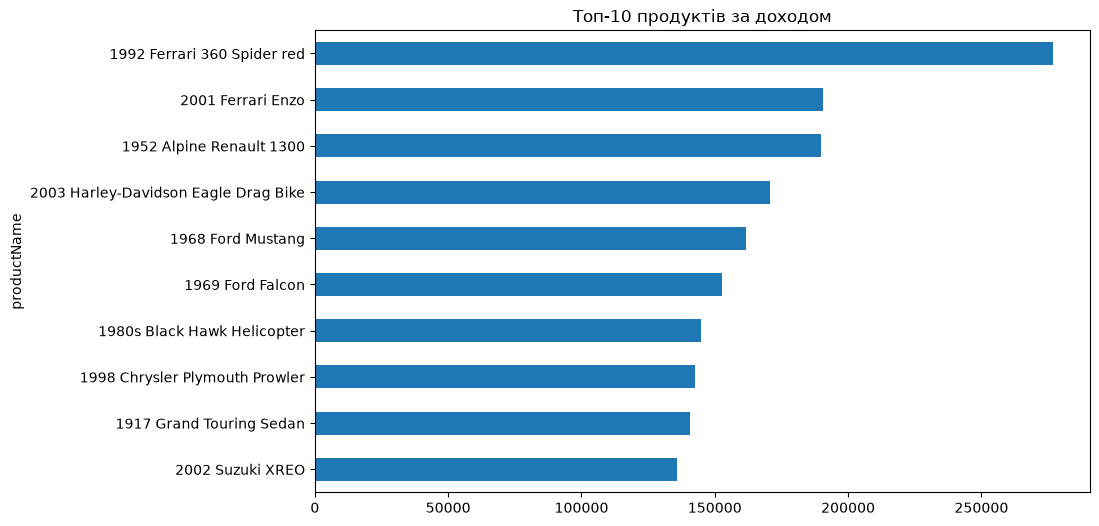

In [51]:
top10 = df.head(10).set_index("productName")["total_revenue"].sort_values()

top10.plot.barh(figsize=(10, 6), title="Топ-10 продуктів за доходом", xlabel="", legend=False)

ratio = df.loc[0, "total_revenue"] / df.loc[9, "total_revenue"]
print(f"ТОП1 перевищує 10-й продукт у {ratio:.2f} раза")

ТОП2 лінії: Classic Cars, Vintage Cars
Разом вони дають 58.84% усіх продажів


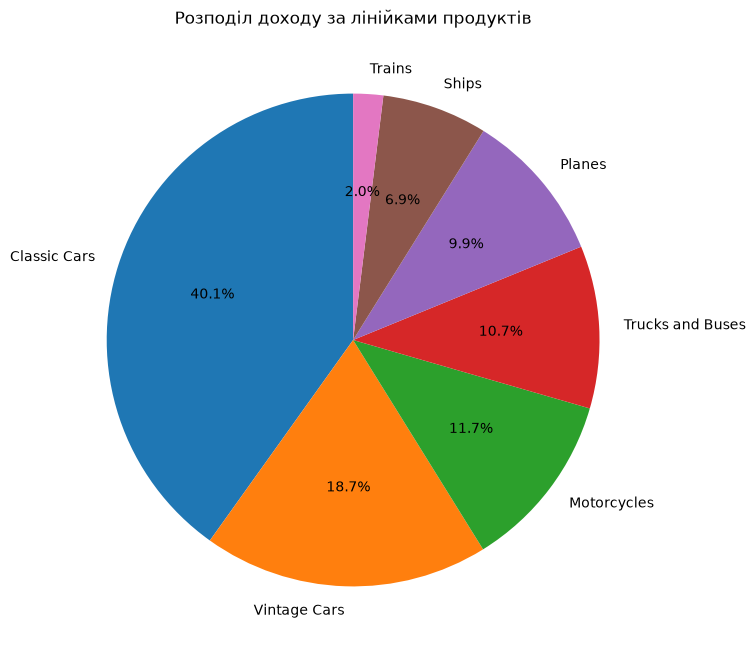

In [52]:
by_line = df.groupby("productLine")["total_revenue"].sum().sort_values(ascending=False)

by_line.plot.pie(
    figsize=(8, 8),
    autopct="%1.1f%%",
    startangle=90,
    ylabel="",
    title="Розподіл доходу за лінійками продуктів",
)

top2_share = by_line.head(2).sum() / by_line.sum() * 100
print(f"ТОП2 лінії: {', '.join(by_line.head(2).index)}")
print(f"Разом вони дають {top2_share:.2f}% усіх продажів")

80% доходу дають 72 продуктів із 109 (66.1% асортименту)


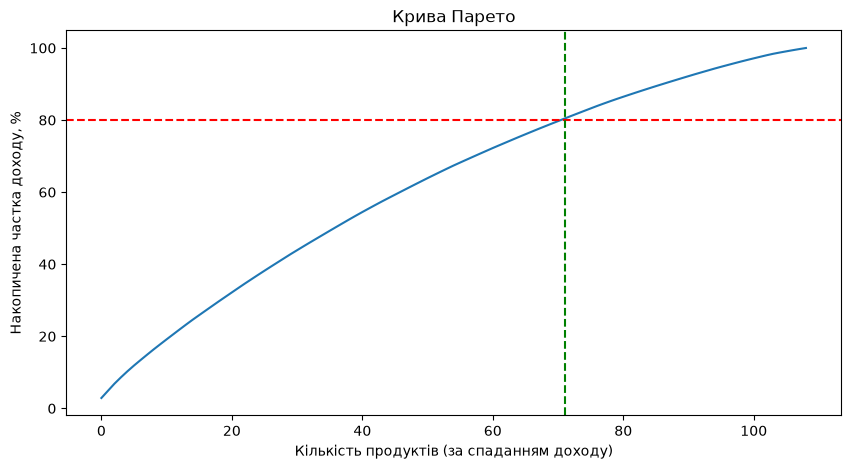

In [53]:
df["cum_pct"] = df["total_revenue"].cumsum() / df["total_revenue"].sum() * 100
n_80 = (df["cum_pct"] < 80).sum() + 1

ax = df["cum_pct"].plot(
    figsize=(10, 5),
    title="Крива Парето",
    xlabel="Кількість продуктів (за спаданням доходу)",
    ylabel="Накопичена частка доходу, %",
    legend=False,
)
ax.axhline(80, color="red", linestyle="--")
ax.axvline(n_80 - 1, color="green", linestyle="--")

print(f"80% доходу дають {n_80} продуктів із {len(df)} ({n_80 / len(df) * 100:.1f}% асортименту)")

In [ ]:
Дослідження: залежність лінійки від найкращого продукту

,products,line_revenue,best_product_revenue,best_product_share_pct
productLine,,,,
Trains,3,188532.92,82617.12,43.82
Ships,9,663998.34,112427.12,16.93
Motorcycles,13,1121426.12,170686.00,15.22
Planes,12,954637.54,144959.91,15.18
Trucks and Buses,11,1024113.57,119085.25,11.63
Vintage Cars,24,1797559.63,140535.60,7.82
Classic Cars,37,3853922.49,276839.98,7.18


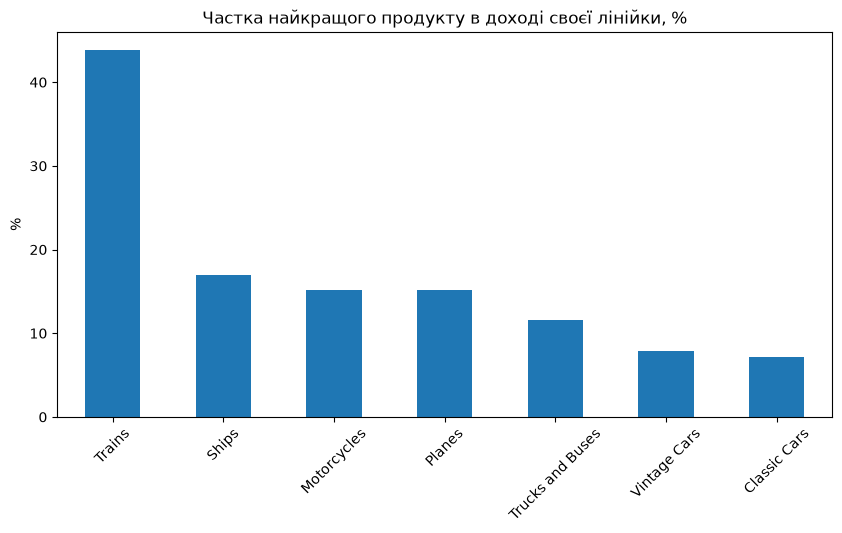

In [67]:
line_stats = df.groupby("productLine").agg(
    products=("productName", "count"),
    line_revenue=("total_revenue", "sum"),
    best_product_revenue=("total_revenue", "max"),
)
line_stats["best_product_share_pct"] = (
    line_stats["best_product_revenue"] / line_stats["line_revenue"] * 100
).round(2)
line_stats = line_stats.sort_values("best_product_share_pct", ascending=False)
display(line_stats)

line_stats["best_product_share_pct"].plot.bar(
    figsize=(10, 5),
    title="Частка найкращого продукту в доході своєї лінійки, %",
    xlabel="",
    ylabel="%",
    rot=45,
);

In [ ]:
У Trains найкращий продукт дає 43,82% доходу лінійки, а в лінійці лише 3 продукти. Це висока концентрація й ризик залежності від одного товару.
У Classic Cars (37 продуктів) і Vintage Cars (24 продукти) частка лідера лише 7,18% і 7,82%. Портфель збалансований.

In [ ]:
ОПЦІОНАЛЬНО. Завдання 4: Аналітичний запит - Динаміка продажів по місяцях (8 балів)
Проведіть аналіз динаміки продажів по місяцях та для цього дістаньте з бази інформацію з наступними полями:

Рік та місяць замовлень
Кількість замовлень за цей рік-місяць
Загальний дохід (quantityOrdered * priceEach) за цей рік-місяць
На який % ми зросли за доходом порівняно з попереднім місяцем
Накопичувальний дохід до цього місяця за рік
Ковзне середнє доходу за 3 місяці
Ранг цього місяця за доходом
Використайте:

CTE для агрегації продажів по місяцях
Віконні функції для розрахунку:
Зростання доходу порівняно з попереднім місяцем (LAG)
Накопичувальний дохід за рік
Ковзне середнє доходу за 3 місяці (AVG OVER)
Ранжування місяців за доходом (RANK)
Після отримання даних з БД побудуйте наступні графіки і напишіть коротко, які висновки з них можна зробити.

Створіть лінійний графік доходу по місяцях. Чи є тред до зростання в даних?
Створіть графік місяць-до-місяця зростання у відсотках.
Створіть heatmap сезонності (місяць vs рік)
Відобразіть козвне середнє разом з динамікою продажів.
Розрахуйте кореляцію між кількістю замовлень та середнім чеком та побудуйте графік розсіювання між цими змінними. Чи є лінійна залежність?
Очікуваний результат кожного графіку - нижче. В першому графіку я додала лінію тренду аби показати тренд. Вам її додавати не треба.

ВАЖЛИВО! Якщо ви захочете назвати одну з колонок .year_month - запит не буде працювати, бо year_month - зарезервоване слово в SQL і 
сприймається як команда. 
    Треба використати іншу назву для відповідної колонки.

In [55]:
import pandas as pd
from sqlalchemy import text

query = text("""
WITH monthly_sales AS (
    SELECT
        YEAR(o.orderDate)                         AS order_year,
        MONTH(o.orderDate)                        AS order_month,
        DATE_FORMAT(o.orderDate, '%Y-%m')         AS ym,
        COUNT(DISTINCT o.orderNumber)             AS orders_count,
        SUM(od.quantityOrdered * od.priceEach)    AS total_revenue
    FROM classicmodels.orders o
    JOIN classicmodels.orderdetails od ON o.orderNumber = od.orderNumber
    GROUP BY order_year, order_month, ym
)
SELECT
    ym,
    order_year,
    order_month,
    orders_count,
    total_revenue,
    ROUND(
        (total_revenue / NULLIF(LAG(total_revenue) OVER (ORDER BY order_year, order_month), 0) - 1) * 100, 2
    ) AS growth_pct,
    SUM(total_revenue) OVER (
        PARTITION BY order_year ORDER BY order_month
    ) AS cumulative_revenue_year,
    ROUND(AVG(total_revenue) OVER (
        ORDER BY order_year, order_month
        ROWS BETWEEN 2 PRECEDING AND CURRENT ROW
    ), 2) AS moving_avg_3m,
    RANK() OVER (ORDER BY total_revenue DESC) AS revenue_rank
FROM monthly_sales
ORDER BY order_year, order_month;
""")

df_monthly = pd.read_sql(query, engine)
df_monthly["total_revenue"] = df_monthly["total_revenue"].astype(float)
df_monthly["cumulative_revenue_year"] = df_monthly["cumulative_revenue_year"].astype(float)
df_monthly["moving_avg_3m"] = df_monthly["moving_avg_3m"].astype(float)
df_monthly["ym"] = pd.to_datetime(df_monthly["ym"])
df_monthly = df_monthly.set_index("ym")
df_monthly.head(10)

,order_year,order_month,orders_count,total_revenue,growth_pct,cumulative_revenue_year,moving_avg_3m,revenue_rank
ym,,,,,,,,
2003-01-01,2003,1,5,116692.77,NaN,116692.77,116692.77,29
2003-02-01,2003,2,3,128403.64,10.04,245096.41,122548.21,28
2003-03-01,2003,3,6,160517.14,25.01,405613.55,135204.52,26
2003-04-01,2003,4,7,185848.59,15.78,591462.14,158256.46,23
2003-05-01,2003,5,6,179435.55,-3.45,770897.69,175267.09,24
2003-06-01,2003,6,7,150470.77,-16.14,921368.46,171918.30,27
2003-07-01,2003,7,7,201940.36,34.21,1123308.82,177282.23,21
2003-08-01,2003,8,5,178257.11,-11.73,1301565.93,176889.41,25
2003-09-01,2003,9,8,236697.85,32.78,1538263.78,205631.77,19


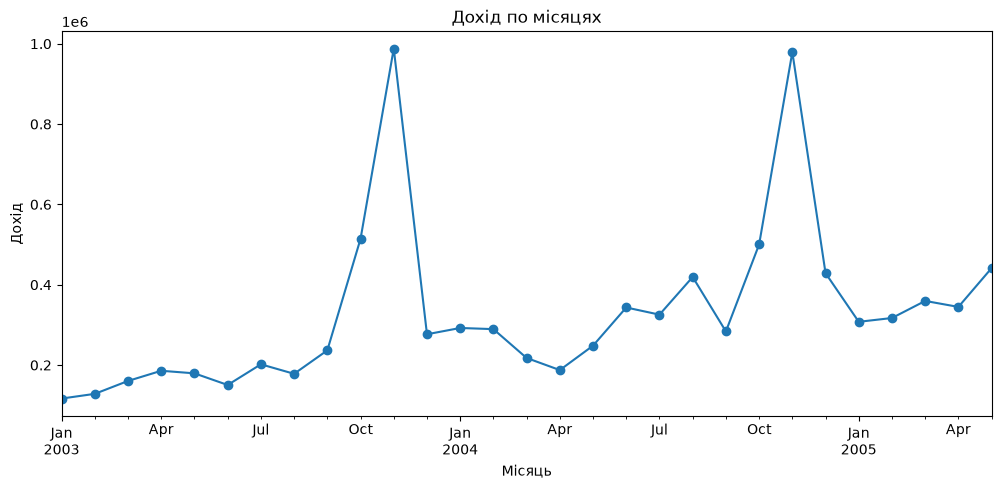

In [59]:
df_monthly["total_revenue"].plot(
    figsize=(12, 5), marker="o",
    title="Дохід по місяцях", ylabel="Дохід", xlabel="Місяць",
);

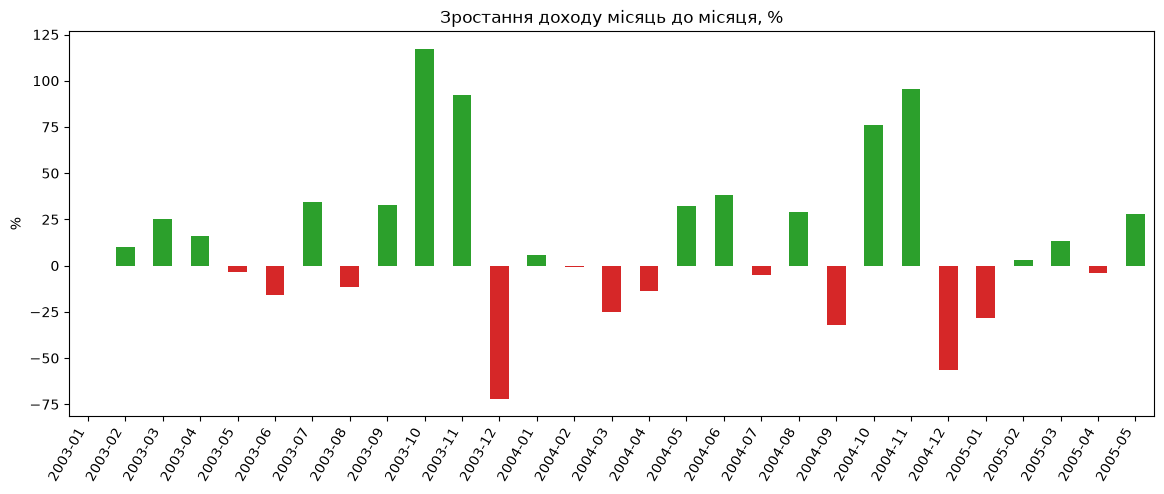

In [58]:
ax = df_monthly["growth_pct"].plot.bar(
    figsize=(14, 5), title="Зростання доходу місяць до місяця, %", ylabel="%", xlabel="",
    color=(df_monthly["growth_pct"] >= 0).map({True: "tab:green", False: "tab:red"}),
)
ax.set_xticklabels(df_monthly.index.strftime("%Y-%m"), rotation=60, ha="right");

In [60]:
pivot = df_monthly.pivot(index="order_month", columns="order_year", values="total_revenue")
pivot.style.background_gradient(cmap="YlOrRd", axis=None).format("{:,.0f}", na_rep="—")

order_year,2003,2004,2005
order_month,,,
1,"116,693","292,385","307,737"
2,"128,404","289,503","317,192"
3,"160,517","217,691","359,712"
4,"185,849","187,576","344,821"
5,"179,436","248,325","441,475"
6,"150,471","343,371",—
7,"201,940","325,563",—
8,"178,257","419,327",—
9,"236,698","283,800",—


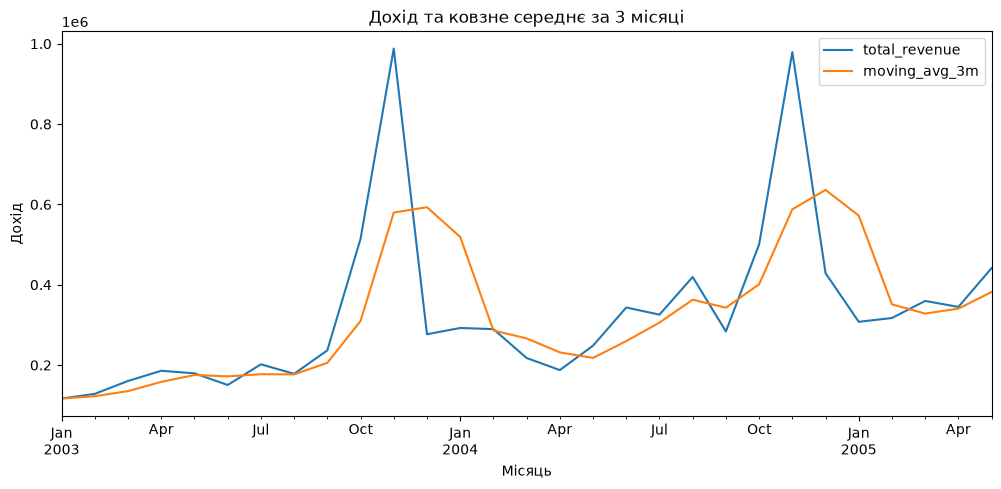

In [64]:
df_monthly[["total_revenue", "moving_avg_3m"]].plot(
    figsize=(12, 5), title="Дохід та ковзне середнє за 3 місяці",
    ylabel="Дохід", xlabel="Місяць",
);

Кореляція Пірсона: 0.017


''

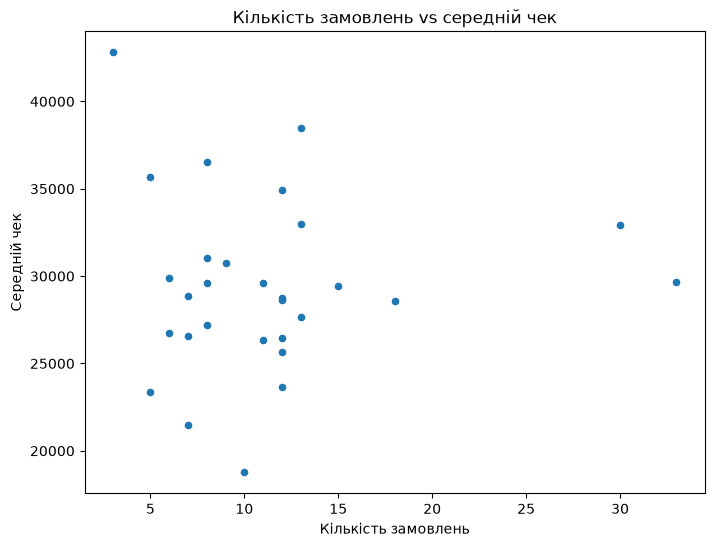

In [66]:
df_monthly["avg_check"] = df_monthly["total_revenue"] / df_monthly["orders_count"]

corr = df_monthly["orders_count"].corr(df_monthly["avg_check"])
print(f"Кореляція Пірсона: {corr:.3f}")

df_monthly.plot.scatter(
    x="orders_count", y="avg_check", figsize=(8, 6),
    title="Кількість замовлень vs середній чек",
    xlabel="Кількість замовлень", ylabel="Середній чек",
)
;

In [ ]:
Кореляція між кількістю замовлень і середнім чеком: r ≈ 0,017, тобто практично нуль. На scatter точки не утворюють смуги, тож лінійної залежності немає.
Більше замовлень у місяці не означає більшого чи меншого середнього чека. Вибірка невелика (~29 місяців), тому висновок обережний.

In [ ]:
Бізнес зростає, але з вираженим піком у листопаді. Для планування запасів і маркетингу варто готуватися до жовтня-листопада.